# SpatioType survival analysis

Kaplan-Meier disease-free survival by SpatioType, in two cohorts:

- **TCGA** — the 858 TCGA breast-cancer patients on which the SpatioTypes were
  defined; KM for all patients and split by clinical subtype (HR+, HER2+, TNBC).
- **METABRIC** — SpatioTypes projected onto METABRIC (see notebook `05`); KM
  overall and by clinical subtype, the SpatioType x ST-cluster heatmap, and KM
  stratified by Nottingham Prognostic Index (NPI).

Inputs are small `.rds` files in `../data/`. R notebook — needs `survival`,
`survminer`, `ggpubr`, `ggsci`, `ComplexHeatmap`, `circlize`, `viridis`.

> **TCGA cohort size note.** The bundled `tcga_spatiotypes_reference.csv`
> contains 858 patients, which is what this notebook (and the rest of the
> `clustering_spatiotypes/` component) uses. If a different starting count
> appears elsewhere in the paper Methods text (for example a count from
> before a downstream QC filter), treat
> `tcga_spatiotypes_reference.csv` as the SpatioType-analysis-of-record
> cohort for reconciliation.

## Setup

In [1]:
suppressPackageStartupMessages({
    library(survival)
    library(survminer)
    library(ggpubr)
    library(ggsci)
    library(dplyr)
})
options(warn = -1)
size_line <- 0.9

# The three named SpatioTypes and their JAMA-palette colours
spatiotype_order  <- c("Immune-Inactive", "Immune-Modulated", "Proliferative")
spatiotype_colors <- pal_jama("default")(4)[c(4, 3, 1)]
names(spatiotype_colors) <- spatiotype_order

## TCGA — derive SpatioTypes

`xy_df.RDS` holds the 11 ST-cluster abundances and survival for 858 TCGA
patients; `feature_df.RDS` holds the per-patient feature profile. The five
metaclusters are recovered by Ward hierarchical clustering of the scaled
feature profiles, then mapped to SpatioType names.

In [2]:
xy_df      <- readRDS("../data/xy_df.RDS")
feature_df <- readRDS("../data/feature_df.RDS")

scaled <- scale(feature_df[, -ncol(feature_df)])
hc     <- hclust(dist(scaled), method = "ward.D2")
metacluster <- cutree(hc, k = 5)

spatiotype_map <- c("1" = "Immune-Modulated", "2" = "Immune-Inactive",
                    "3" = "Lipid-Metabolic",  "4" = "Proliferative",
                    "5" = "Hedgehog-Active")
xy_df$SpatioType <- unname(spatiotype_map[as.character(metacluster)])
table(xy_df$SpatioType)


 Hedgehog-Active  Immune-Inactive Immune-Modulated  Lipid-Metabolic 
              11              218              562                5 
   Proliferative 
              62 

## TCGA — Kaplan-Meier, all patients

Disease-free interval (DFI) by SpatioType, restricted to the three named
SpatioTypes. The p-value is a one-sided log-rank test of Immune-Inactive vs
Immune-Modulated (the survival contrast of interest).

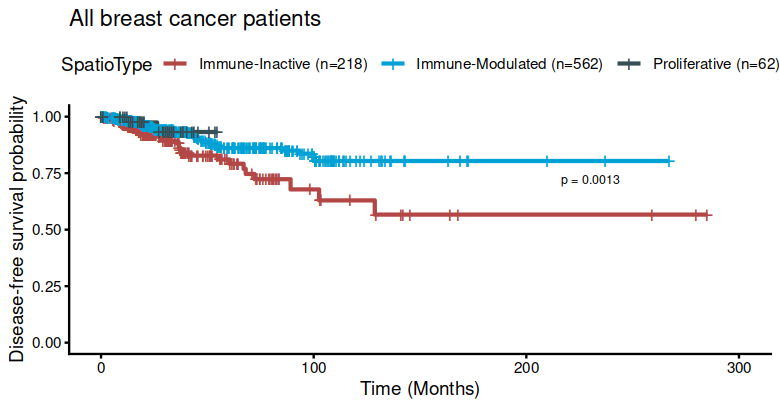

In [3]:
tcga <- xy_df[xy_df$SpatioType %in% spatiotype_order &
               !is.na(xy_df$DFI) & !is.na(xy_df$DFI.time), ]
tcga$SpatioType <- factor(tcga$SpatioType, levels = spatiotype_order)

# one-sided log-rank, Immune-Inactive vs Immune-Modulated
pair <- tcga[tcga$SpatioType %in% c("Immune-Inactive", "Immune-Modulated"), ]
sd   <- survdiff(Surv(DFI.time, DFI) ~ SpatioType, data = pair)
hr   <- (sd$obs[1] / sd$exp[1]) / (sd$obs[2] / sd$exp[2])
p1   <- if (hr > 1) sd$pvalue / 2 else 1 - sd$pvalue / 2

fit <- survfit(Surv(DFI.time, DFI) ~ SpatioType, data = tcga)
cnt <- table(tcga$SpatioType)
g <- ggsurvplot(fit, data = tcga, palette = unname(spatiotype_colors[levels(tcga$SpatioType)]),
                legend.title = "SpatioType",
                legend.labs = paste0(levels(tcga$SpatioType), " (n=", cnt, ")"),
                conf.int = FALSE, pval = FALSE, risk.table = FALSE, size = size_line,
                xlab = "Time (Months)", ylab = "Disease-free survival probability",
                title = "All breast cancer patients", ggtheme = theme_classic())
g$plot <- g$plot + annotate("text", x = 230, y = 0.72, size = 2.5,
                            label = paste0("p = ", format(p1, digits = 2)))
options(repr.plot.width = 6.5, repr.plot.height = 3.4); print(g)

## TCGA — Kaplan-Meier by clinical subtype

The same DFI analysis within each clinical subtype (HR+, HER2+, TNBC).

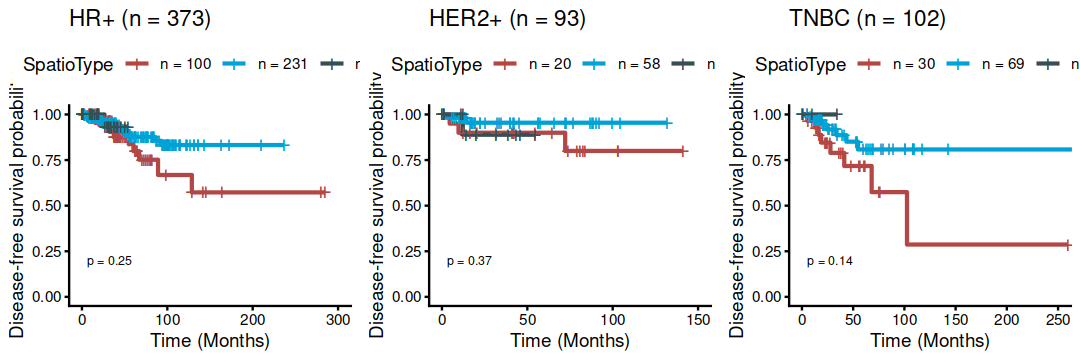

In [4]:
subtype_plots <- list()
for (st in c("HR+", "HER2+", "TNBC")) {
    sub <- tcga[tcga$class == st, ]
    sub <- sub[!is.na(sub$SpatioType), ]
    sub$SpatioType <- droplevels(factor(sub$SpatioType, levels = spatiotype_order))
    fit <- survfit(Surv(DFI.time, DFI) ~ SpatioType, data = sub)
    cnt <- table(sub$SpatioType)
    sp <- ggsurvplot(fit, data = sub,
                     palette = unname(spatiotype_colors[levels(sub$SpatioType)]),
                     legend.title = "SpatioType", legend.labs = paste0("n = ", cnt),
                     conf.int = FALSE, pval = TRUE, pval.size = 2.5, risk.table = FALSE,
                     size = size_line, xlab = "Time (Months)",
                     ylab = "Disease-free survival probability",
                     title = paste0(st, " (n = ", nrow(sub), ")"),
                     ggtheme = theme_classic())
    subtype_plots[[st]] <- sp$plot
}
options(repr.plot.width = 9, repr.plot.height = 3)
ggarrange(plotlist = subtype_plots, ncol = 3, nrow = 1)

## METABRIC — Kaplan-Meier overall

SpatioTypes projected onto METABRIC (notebook `05`); relapse-free survival
(RFS) by SpatioType. `km_plot_data.rds` carries the survival table and the
plotting parameters.

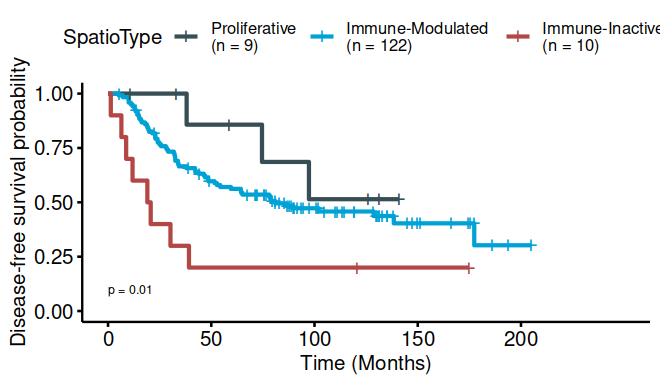

In [5]:
km_input <- readRDS("../data/km_plot_data.rds")
km_data  <- km_input$data

km_fit <- survfit(Surv(RFS.time, RFS) ~ spatiotype, data = km_data)
p <- ggsurvplot(km_fit, data = km_data, legend.title = "SpatioType",
                legend.labs = km_input$params$legend_labels,
                palette = km_input$params$cluster_colors,
                conf.int = FALSE, pval = FALSE, risk.table = FALSE, size = size_line,
                xlab = "Time (Months)", ylab = "Disease-free survival probability",
                xlim = c(0, 250), ggtheme = theme_pubr())
pval <- surv_pvalue(km_fit, data = km_data)$pval
p$plot <- p$plot + annotate("text", x = 0, y = 0.1, hjust = 0, size = 2.5,
                            label = paste0("p = ", round(pval, 3)))
options(repr.plot.width = 5.5, repr.plot.height = 3.2); print(p)

## METABRIC — Kaplan-Meier by clinical subtype

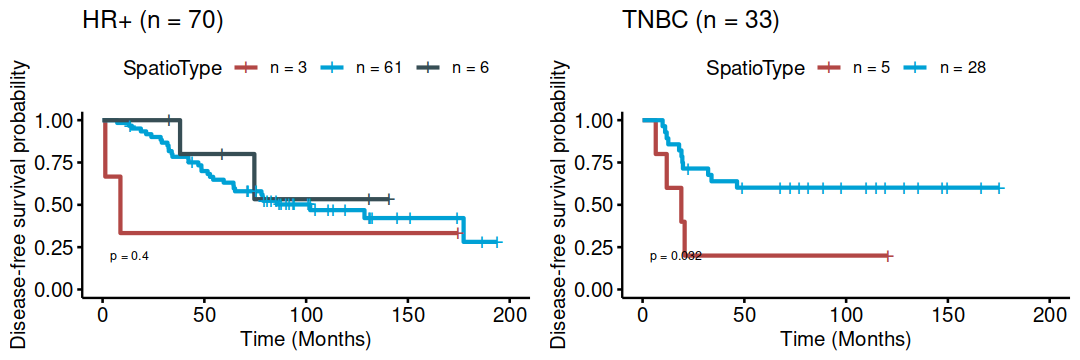

In [6]:
xy_df_main <- readRDS("../data/km_subtype_data.rds")

plot_list <- list()
for (subtype in c("HR+", "HER2+", "TNBC")) {
    d <- xy_df_main[xy_df_main$clinical_subtype == subtype &
                    !is.na(xy_df_main$RFS.time) & !is.na(xy_df_main$RFS) &
                    !is.na(xy_df_main$spatiotype), ]
    d$spatiotype <- factor(d$spatiotype, levels = spatiotype_order)
    present <- names(table(d$spatiotype))[table(d$spatiotype) >= 3]
    d <- d[d$spatiotype %in% present, ]
    d$spatiotype <- factor(d$spatiotype, levels = present)
    if (length(present) < 2 || nrow(d) < 5) next

    fit <- survfit(Surv(RFS.time, RFS) ~ spatiotype, data = d)
    sp <- ggsurvplot(fit, data = d, legend.title = "SpatioType",
                     legend.labs = paste0("n = ", as.numeric(table(d$spatiotype))),
                     palette = unname(spatiotype_colors[present]),
                     conf.int = FALSE, pval = TRUE, pval.size = 2.5, risk.table = FALSE,
                     size = size_line, xlab = "Time (Months)",
                     ylab = "Disease-free survival probability",
                     title = paste0(subtype, " (n = ", nrow(d), ")"),
                     ggtheme = theme_pubr())
    plot_list[[subtype]] <- sp$plot
}
options(repr.plot.width = 9, repr.plot.height = 3)
ggarrange(plotlist = plot_list, ncol = length(plot_list), nrow = 1)

## METABRIC — SpatioType heatmap

Per-patient ST-cluster composition (row z-scored), columns grouped and
clustered within SpatioType.

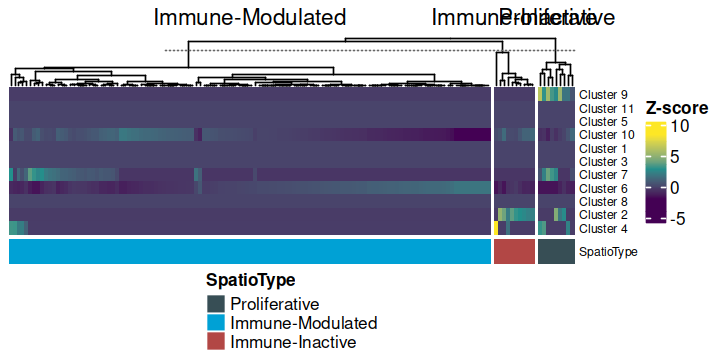

In [7]:
suppressPackageStartupMessages({
    library(ComplexHeatmap); library(circlize); library(viridis); library(grid)
})
hm <- readRDS("../data/heatmap_data.rds")
cell_type_matrix <- hm$cell_type_matrix
annotation_data  <- hm$annotation_data
colnames(cell_type_matrix) <- gsub("_", " ", colnames(cell_type_matrix))

rr <- c("Cluster 9","Cluster 11","Cluster 5","Cluster 10","Cluster 1","Cluster 3",
        "Cluster 7","Cluster 6","Cluster 8","Cluster 2","Cluster 4")
cell_type_matrix <- cell_type_matrix[, intersect(rr, colnames(cell_type_matrix)), drop = FALSE]

sp_order <- c("Proliferative", "Immune-Modulated", "Immune-Inactive")
sample_order <- unlist(lapply(sp_order, function(s)
    rownames(annotation_data)[annotation_data$spatiotype == s]))
mat <- t(cell_type_matrix[sample_order, ])
mat <- t(apply(mat, 1, function(x) if (sd(x) == 0) x * 0 else scale(x)[, 1]))

ann <- HeatmapAnnotation(
    SpatioType = factor(annotation_data[sample_order, "spatiotype"], levels = sp_order),
    col = list(SpatioType = c("Immune-Inactive"   = pal_jama("default")(4)[4],
                              "Proliferative"      = pal_jama("default")(4)[1],
                              "Immune-Modulated"   = pal_jama("default")(4)[3])),
    annotation_name_gp = gpar(fontsize = 7))
ht <- Heatmap(mat, name = "Z-score", cluster_rows = FALSE, cluster_columns = TRUE,
              column_split = factor(annotation_data[sample_order, "spatiotype"], levels = sp_order),
              col = colorRamp2(c(min(mat), 2.85, max(mat)), viridis(3)),
              show_column_names = FALSE, bottom_annotation = ann,
              row_names_gp = gpar(fontsize = 7), rect_gp = gpar(col = NA))
options(repr.plot.width = 6, repr.plot.height = 3)
draw(ht, heatmap_legend_side = "right", annotation_legend_side = "bottom")

## METABRIC — Kaplan-Meier by Nottingham Prognostic Index

RFS by SpatioType (Immune-Inactive vs Immune-Modulated) within the Moderate
and Poor NPI groups.

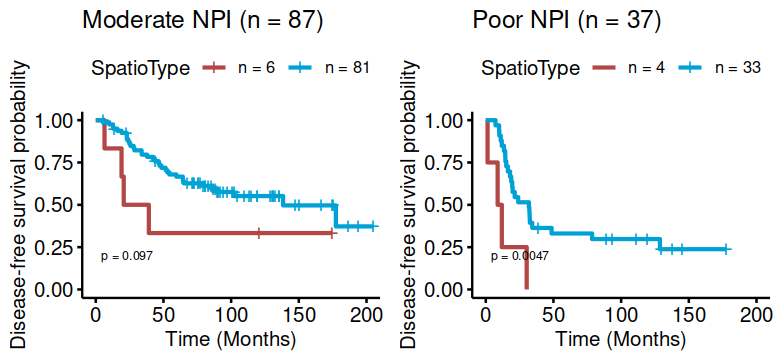

In [8]:
ss <- readRDS("../data/npi_km_data.rds")

npi_plots <- list()
for (npi_group in c("Moderate", "Poor")) {
    d <- ss[ss$NPI_group == npi_group &
            ss$Subtypes %in% c("Immune-Inactive", "Immune-Modulated") &
            !is.na(ss$RFS_MONTHS) & !is.na(ss$RFS_STATUS), ]
    d <- droplevels(d)
    if (nrow(d) < 5) next
    present <- intersect(spatiotype_order, unique(as.character(d$Subtypes)))
    d$Subtypes <- factor(d$Subtypes, levels = present)
    d$event <- as.numeric(d$RFS_STATUS == "1:Recurred")
    fit <- survfit(Surv(RFS_MONTHS, event) ~ Subtypes, data = d)
    sp <- ggsurvplot(fit, data = d, legend.title = "SpatioType",
                     legend.labs = paste0("n = ", as.numeric(table(d$Subtypes))),
                     palette = unname(spatiotype_colors[present]),
                     conf.int = FALSE, pval = TRUE, pval.size = 2.5, risk.table = FALSE,
                     size = size_line, xlab = "Time (Months)",
                     ylab = "Disease-free survival probability",
                     title = paste0(npi_group, " NPI (n = ", nrow(d), ")"),
                     ggtheme = theme_pubr())
    npi_plots[[npi_group]] <- sp$plot
}
options(repr.plot.width = 6.5, repr.plot.height = 3)
ggarrange(plotlist = npi_plots, ncol = length(npi_plots), nrow = 1)